# Initialise tree community for LANDIS-II based on NBI

Last updated: 2026-08-25 <br>
Author: Stefan Vriend

## Background
An essential component of initialising LANDIS-II (with the Biomass Succession Extension) for the Veluwe is the initial tree community, which is made up of species-age groups and their respective biomass.  
The national forest inventory (NBI) data, which is the most comprehensive forest dataset in the Netherlands, has information on species, diameter-at-breast-height (dbh), and biomass of individual trees, but not their age.  
In this notebook, we explore different dbh-height-age models to estimate age for individual trees.

## Setup
#### Settings

In [1]:
conf_input_location <- "/home/jovyan/Cloud Storage/naa-vre-public/vl-veluwe-forest-model"
conf_tmp_data <- "/tmp/data"

In [244]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load("dplyr", "terra", "sf", "minpack.lm", "mgcv", "purrr", "ggplot2", "ggtext", "cowplot")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


rootSolve installed



#### Veluwe map

In [3]:
# Veluwe map retriever
#=========================================================
# Load and transform the Natura2000 Veluwe geopackage
natura2000_sf <- sf::read_sf("https://service.pdok.nl/rvo/natura2000/atom/downloads/natura2000.gpkg") |>
sf::st_transform(28992)

# Create the veluwe sf by filtering the Natura2000 shapefile 
veluwe_sf <- natura2000_sf |>
  dplyr::filter(objectid == 4049)

# Load LGN map
# LGN is Landelijk Grondgebruik Nederland, a national map about land use in the Netherlands.
# We use LGN5, which represents land use in 2003-2004 with a 25 meter resolution
# TODO: add option to select other versions of LGN
lgn5 <- terra::rast(file.path(conf_input_location, "LGN5.tif"))

# Turn sf object into vector
veluwe_vect <- terra::vect(veluwe_sf)

# Crop LGN map to Veluwe Natura2000
lgn5_veluwe <- terra::crop(lgn5, veluwe_vect) |>
    terra::mask(veluwe_vect)

# Retain cells that correspond to forest (11, broadleaf forest; 12, coniferous forest)
forest_codes <- c(11, 12)
veluwe_forest <- terra::ifel(lgn5_veluwe %in% forest_codes, 1, NA)

# Save the as geopackage to tmp data so that it can be used in later cells 
#veluwe_datafile <- file.path(conf_tmp_data, "veluwe.gpkg")
#sf::st_write(veluwe_forest, veluwe_datafile, append = FALSE)

#### National forest inventory data
We load the data for the fifth national forest inventory (MFV), which was conducted in 2003-2004.

In [4]:
# Load NBI data
#=========================================================
# Download the Microsoft Access database file that contains the most up-to-date data
# from MFV (NBI-5), NBI-6 and NBI-7 from the Probos website 
if (!file.exists(file.path(conf_tmp_data, "NBI.zip"))) {
    url <- "https://probos.nl/DB/NBI-7_openbare_database.zip"
    download.file(url, file.path(conf_tmp_data, "NBI.zip"), mode = "wb")
    unzip(file.path(conf_tmp_data, "NBI.zip"), exdir = conf_tmp_data)
}

# Remove space in unzipped file name
new_file <- file.path(conf_tmp_data, "NBI7_openbare_database_definitief_UpdateJuli2024.accdb")
if (!file.exists(new_file)) {
    file.rename(from = file.path(conf_tmp_data, "NBI7_openbare database_definitief_UpdateJuli2024.accdb"),
                to = new_file)
}
    
# Retrieve the relevant tables from the Microsoft Access database 
# - data_MFV_proefbomen contains measurements on individual sample trees, measurements of which are used to determine volume, biomass and growth of all other trees in a plot
# - data_MFV_boomgegevens contains measurements on individual trees within a plot, such as species and dbh, and estimations of volume, biomass and growth of trees
# - data_MFV_plotdefinitie contains a description of all MFV plots, such as plot id (plotnummer), location, surface area, municipality
# - data_MFV_plotmetingen contains measurements at the MFV plot level, such as sprouting year, soil type, ground water table
data_MFV_proefbomen <- Hmisc::mdb.get(new_file, tables = "data_MFV_proefbomen")
data_MFV_boomgegevens <- Hmisc::mdb.get(new_file, tables = "data_MFV_boomgegevens")
data_MFV_plotdefinitie <- Hmisc::mdb.get(new_file, tables = "data_MFV_plotdefinitie")
data_MFV_plotmetingen <- Hmisc::mdb.get(new_file, tables = "data_MFV_plotmetingen")

# Wrangle Access tables
# - convert diameter columns to cm
# - rename columns to English names and lowercase
# - retain only necessary columns
nbi5_forest_data <- data_MFV_boomgegevens |>
    tibble::as_tibble() |>
    dplyr::mutate(dbh_cm = .data$DIAMETER.MM / 10) |>
    dplyr::select("tree_number" = "BOOMNUMMER", "plot_number" = "PLOTNUMMER", "species_name" = "BOOMSOORT", "species_code" = "CODE.BOOMSOORT", 
                  "basal_area_m2" = "Grondvlak.m2", "dbh_cm", "volume_dm3" = "Volume.m3", "number_of_stems_ha" = "NstamHA", "biomass_stem_kg" = "Stambiomassa.kg", 
                  "biomass_branch_kg" = "Takbiomassa.kg", "biomass_leaf_kg" = "Bladbiomassa.kg", "biomass_root_kg" = "Wortelbiomassa.kg") |>
    type.convert(as.is = TRUE)

nbi5_plot_definition <- data_MFV_plotdefinitie |>
    dplyr::select("plot_number" = "PLOTNUMMER", "grid" = "GRID") |>
    type.convert(as.is = TRUE)

nbi5_plot_measurements <- data_MFV_plotmetingen |>
    dplyr::mutate("plot_size_ha" = .data$Plotoppervlak.totaal.dm2 / 1e06) |>
    dplyr::select("plot_number" = "PLOTNUMMER", "plot_size_ha", "top10_code" = "TOP10CODE", "measurement_date" = "OPNAMEDATUM", 
                  "germination_year" = "KIEMJAAR", "density_ha" = "Stamtal.ha.levend") |>
    type.convert(as.is = TRUE) |>
    dplyr::mutate("measurement_date" = as.Date(.data$measurement_date))

nbi5_sample_trees <- data_MFV_proefbomen |>
    dplyr::mutate("dbh_cm" = .data$DIAMETER.MM / 10) |>
    dplyr::select("plot_number" = "PLOTNUMMER", "species_name" = "BOOMSOORT", "species_code" = "CODE.BOOMSOORT", "height_m" = "HOOGTE.M", "dbh_cm") |>
    type.convert(as.is = TRUE)

## TODO
# 1a. Calculate ages
# 1b. What to do with 'rest' species?
# 2. Aggregate biomass by age class and scale to density

[1] TRUE

25 variables; Processing variable:1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 


In [5]:
# Filter NBI plots that are within the Veluwe
veluwe_plots <- nbi5_plot_definition |> 
    dplyr::mutate("lat" = as.integer(stringr::str_extract(.data$grid, "(?<=N)\\d+")) * 1000 + 500,
                  "lon" = as.integer(stringr::str_extract(.data$grid, "(?<=E)\\d+")) * 1000 + 500) |> 
    sf::st_as_sf(coords = c("lon", "lat"), 
                 crs = 3035) |> 
    sf::st_transform(crs = sf::st_crs(veluwe_forest)) |> 
    {\(.) dplyr::mutate(.,
                        "x" = sf::st_coordinates(.)[,1], 
                        "y" = sf::st_coordinates(.)[,2])}() |>
    terra::vect() |>
    terra::crop(veluwe_forest) |>
    terra::as.data.frame() |>
    dplyr::left_join(nbi5_plot_measurements, by = "plot_number")

# Associate age (based on germination year, kiemjaar) with sample trees
veluwe_sample_trees <- nbi5_sample_trees |> 
  dplyr::right_join(veluwe_plots |> 
                      dplyr::select("plot_number", "measurement_date", "germination_year"),
                    by = "plot_number") |> 
  dplyr::mutate("age" = lubridate::year(.data$measurement_date) - .data$germination_year)

#### Helper functions

In [203]:
# Calculate goodness-of-fit metrics
# Coefficient of determination
pseudo_r2 <- function(x, xpred) {

    ss_res <- sum((x - xpred)^2) # residual sum of squares
    ss_tot <- sum((x - mean(x))^2) # total sum of squares

    1 - (ss_res / ss_tot) # pseudo coefficient of determination
    
}

# Root mean squared error
rmse <- function(x, xpred) {

    sqrt(mean((x - xpred)^2)) # root mean squared error
    
}

## Exploring different approaches
We explore two approaches:

1. One-step approach; estimate age from dbh-age model
2. Two-step approach; estimate height from dbh-model model, estimate age from height-age model

General limitations that we are aware of:

- We mostly ignore the effect of thinning (i.e., removal of trees) on growth of remaining trees
- We do not properly account for propagation of uncertainty when applying the two models sequentially
- NBI trees with known dbh and height only have a germination year (NL: kiemjaar) at the stand level

#### Part 1: Estimate age from dbh
Following Rohner et al. 2013 (https://doi.org/10.1016/j.foreco.2013.04.034), we fit a series of polynomial models:

1. $Age \sim DBH$
2. $Age \sim DBH + DBH^2$
3. $Age \sim DBH + DBH^2 + DBH^3$
4. $Age \sim DBH + DBH^{1.5} + DBH^2$ from Loewenstein et al. 2000 (https://doi.org/10.1139/x00-036)

In [298]:
model_outputs <- purrr::map(
    .x = species_list,
    .f = ~{
        
        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == .x)
        
        mod1 <- lm(age ~ dbh_cm, data = selected_data)
        mod2 <- lm(age ~ dbh_cm + I(dbh_cm^2), data = selected_data)
        mod3 <- lm(age ~ dbh_cm + I(dbh_cm^2) + I(dbh_cm^3), data = selected_data)
        mod4 <- lm(age ~ dbh_cm + I(dbh_cm^1.5) + I(dbh_cm^2), data = selected_data)
                  
        list("lin" = mod1, "quad" = mod2, "cube" = mod3, "loew" = mod4)
})

# Predict heights for range of measured dbh values
pred_outputs <- purrr::map2(
    .x = species_list,
    .y = model_outputs,
    .f = ~{

        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == .x)

        dummy_dbh <- seq(min(selected_data$dbh_cm), max(selected_data$dbh_cm), length.out = 1000)
        
        tibble::tibble(dbh = rep(dummy_dbh, length(.y)),
                       age = unlist(lapply(.y, \(.) predict(., list(dbh_cm = dummy_dbh)))),
                       model = rep(names(.y), each = 1000),
                       species = .x)
})

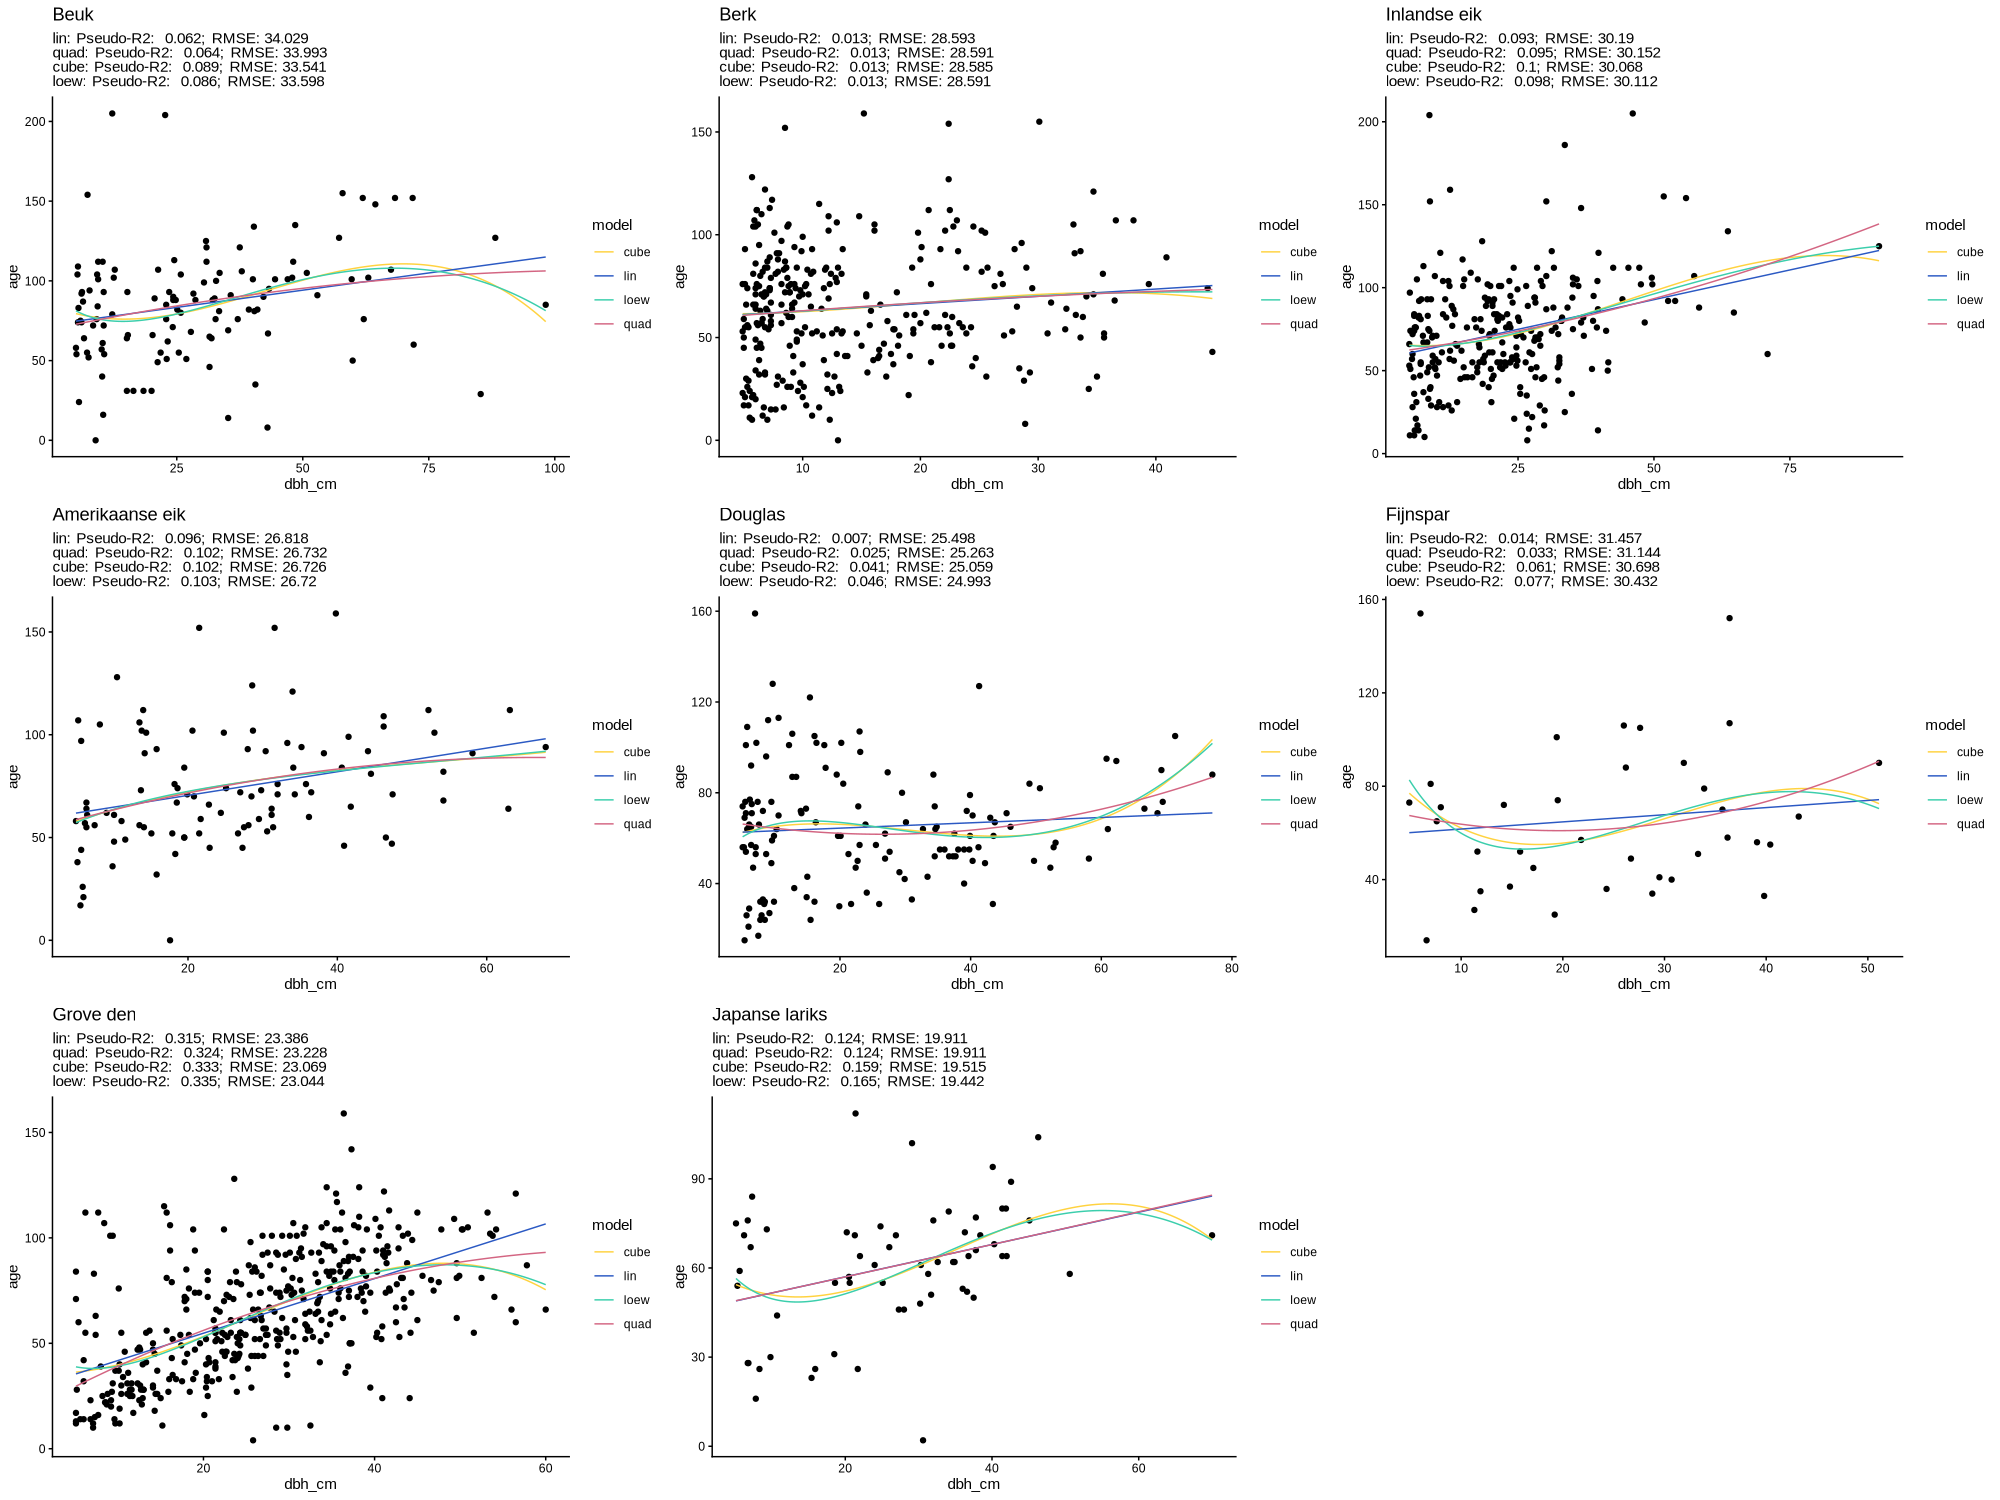

In [301]:
colour_vector <- c("lin" = "#2b59c3", "quad" = "#d36582", "cube" = "#ffd23f", "loew" = "#3bceac")
plot_list <- purrr::map(
    .x = species_list,
    .f = ~{
        
        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == .x)

        models <- model_outputs[[which(species_list == .x)]] # remove non-convergent models

        # Add pseudo-r2 and rmse for each model
        subtitle <- purrr::map2_chr(.x = models, 
                                    .y = names(models),
                                    .f = ~paste0(.y,": ", "Pseudo-R2:&nbsp;", round(pseudo_r2(selected_data$age, fitted(.x)), 3), ";&nbsp;RMSE:&nbsp;", round(rmse(selected_data$age, fitted(.x)), 3))) |>
            paste(collapse = "<br>")
        
        ggplot2::ggplot() +
            ggplot2::geom_point(data = selected_data, mapping = ggplot2::aes(x = dbh_cm, y = age)) +
            ggplot2::geom_line(data = pred_outputs[[which(species_list == .x)]], mapping = ggplot2::aes(x = dbh, y = age, color = model, group = model)) +
            ggplot2::scale_colour_manual(values = colour_vector) +
            ggplot2::labs(title = .x, subtitle = subtitle) +
            ggplot2::theme_classic() +
            ggplot2::theme(plot.subtitle = ggtext::element_markdown())
        
    }
)

options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
cowplot::plot_grid(plotlist = plot_list)

> **Conclusion**  
>  
> The fit of these models is poor at best. Perhaps we get better results for the two-step approach.

#### Part 2a: Estimate height from dbh
Following West & Strimbu 2025 (https://doi.org/10.1093/forestry/cpaf010), who performed a comparison of height-dbh growth models, we try their best-performing models:

(1) Sibbessen model: $H = 1.3 + aD^{{bD}^{c}}$

(2) power model: $H = 1.3 + aD^b$

(3) Chapman-Richards model: $H = 1.3 + a(1 - e^{bD})^c$

(4) Generalised additive model: $H = a + f_{1}(D_{1}) + ... + f_{p}(D_{p})$, where $f_{i}(D_{i})$ are thin-plate splines

In [204]:
# Run all 4 height-dbh models for each species
species_list <- c("Beuk", "Berk", "Inlandse eik", "Amerikaanse eik", "Douglas", "Fijnspar", "Grove den", "Japanse lariks")

model_outputs <- purrr::map(
    .x = species_list,
    .f = ~{
        selected_data <- veluwe_sample_trees |> dplyr::filter(species_name == .x)
        
        # power model
        lin_mod <- lm(log10(height_m) ~ log10(dbh_cm), data = selected_data)
        mod1 <- tryCatch(expr = minpack.lm::nlsLM(height_m ~ 1.3 + a * dbh_cm ^ b, data = selected_data, start = list(a = 10 ^ coef(lin_mod)[1], b = coef(lin_mod)[2]), control = list(maxiter = 1000)),
                         error = function(e) NULL)
    
        # Sibbesen model
        mod2 <- tryCatch(expr = minpack.lm::nlsLM(height_m ~ 1.3 + a * dbh_cm ^ (b * dbh_cm ^ c), data = selected_data, start = list(a = 10 ^ coef(lin_mod)[1], b = coef(lin_mod)[2], c = log10(coef(lin_mod)[2])), control = list(maxiter = 1000)),
                         error = function(e) NULL)
    
        # Chapman-Richards model
        lin_mod_lm <- lm(log(height_m) ~ log(dbh_cm), data = selected_data)
        mod3 <- tryCatch(expr = minpack.lm::nlsLM(height_m ~ 1.3 + a * (1 - exp(b * dbh_cm)) ^ c, data = selected_data, start = list(a = exp(coef(lin_mod_lm)[1]), b = log(coef(lin_mod_lm)[2]), c = coef(lin_mod_lm)[2]), control = list(maxiter = 1000)),
                         error = function(e) NULL)
        
        # Generalised additive model
        mod4 <- tryCatch(expr = mgcv::gam(height_m ~ s(dbh_cm), data = selected_data, method = "REML"),
                         error = function(e) NULL)
        
        list("pow" = mod1, "sib" = mod2, "cr" = mod3, "gam" = mod4)
})

# Predict heights for range of measured dbh values
pred_outputs <- purrr::map2(
    .x = species_list,
    .y = model_outputs,
    .f = ~{

        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == .x)
        model_list <- purrr::compact(.y) # remove non-convergent models
        dummy_dbh <- seq(min(selected_data$dbh_cm), max(selected_data$dbh_cm), length.out = 1000)
        
        tibble::tibble(dbh = rep(dummy_dbh, length(model_list)),
                       height = unlist(lapply(model_list, \(.) predict(., list(dbh_cm = dummy_dbh)))),
                       model = rep(names(model_list), each = 1000),
                       species = .x)
})

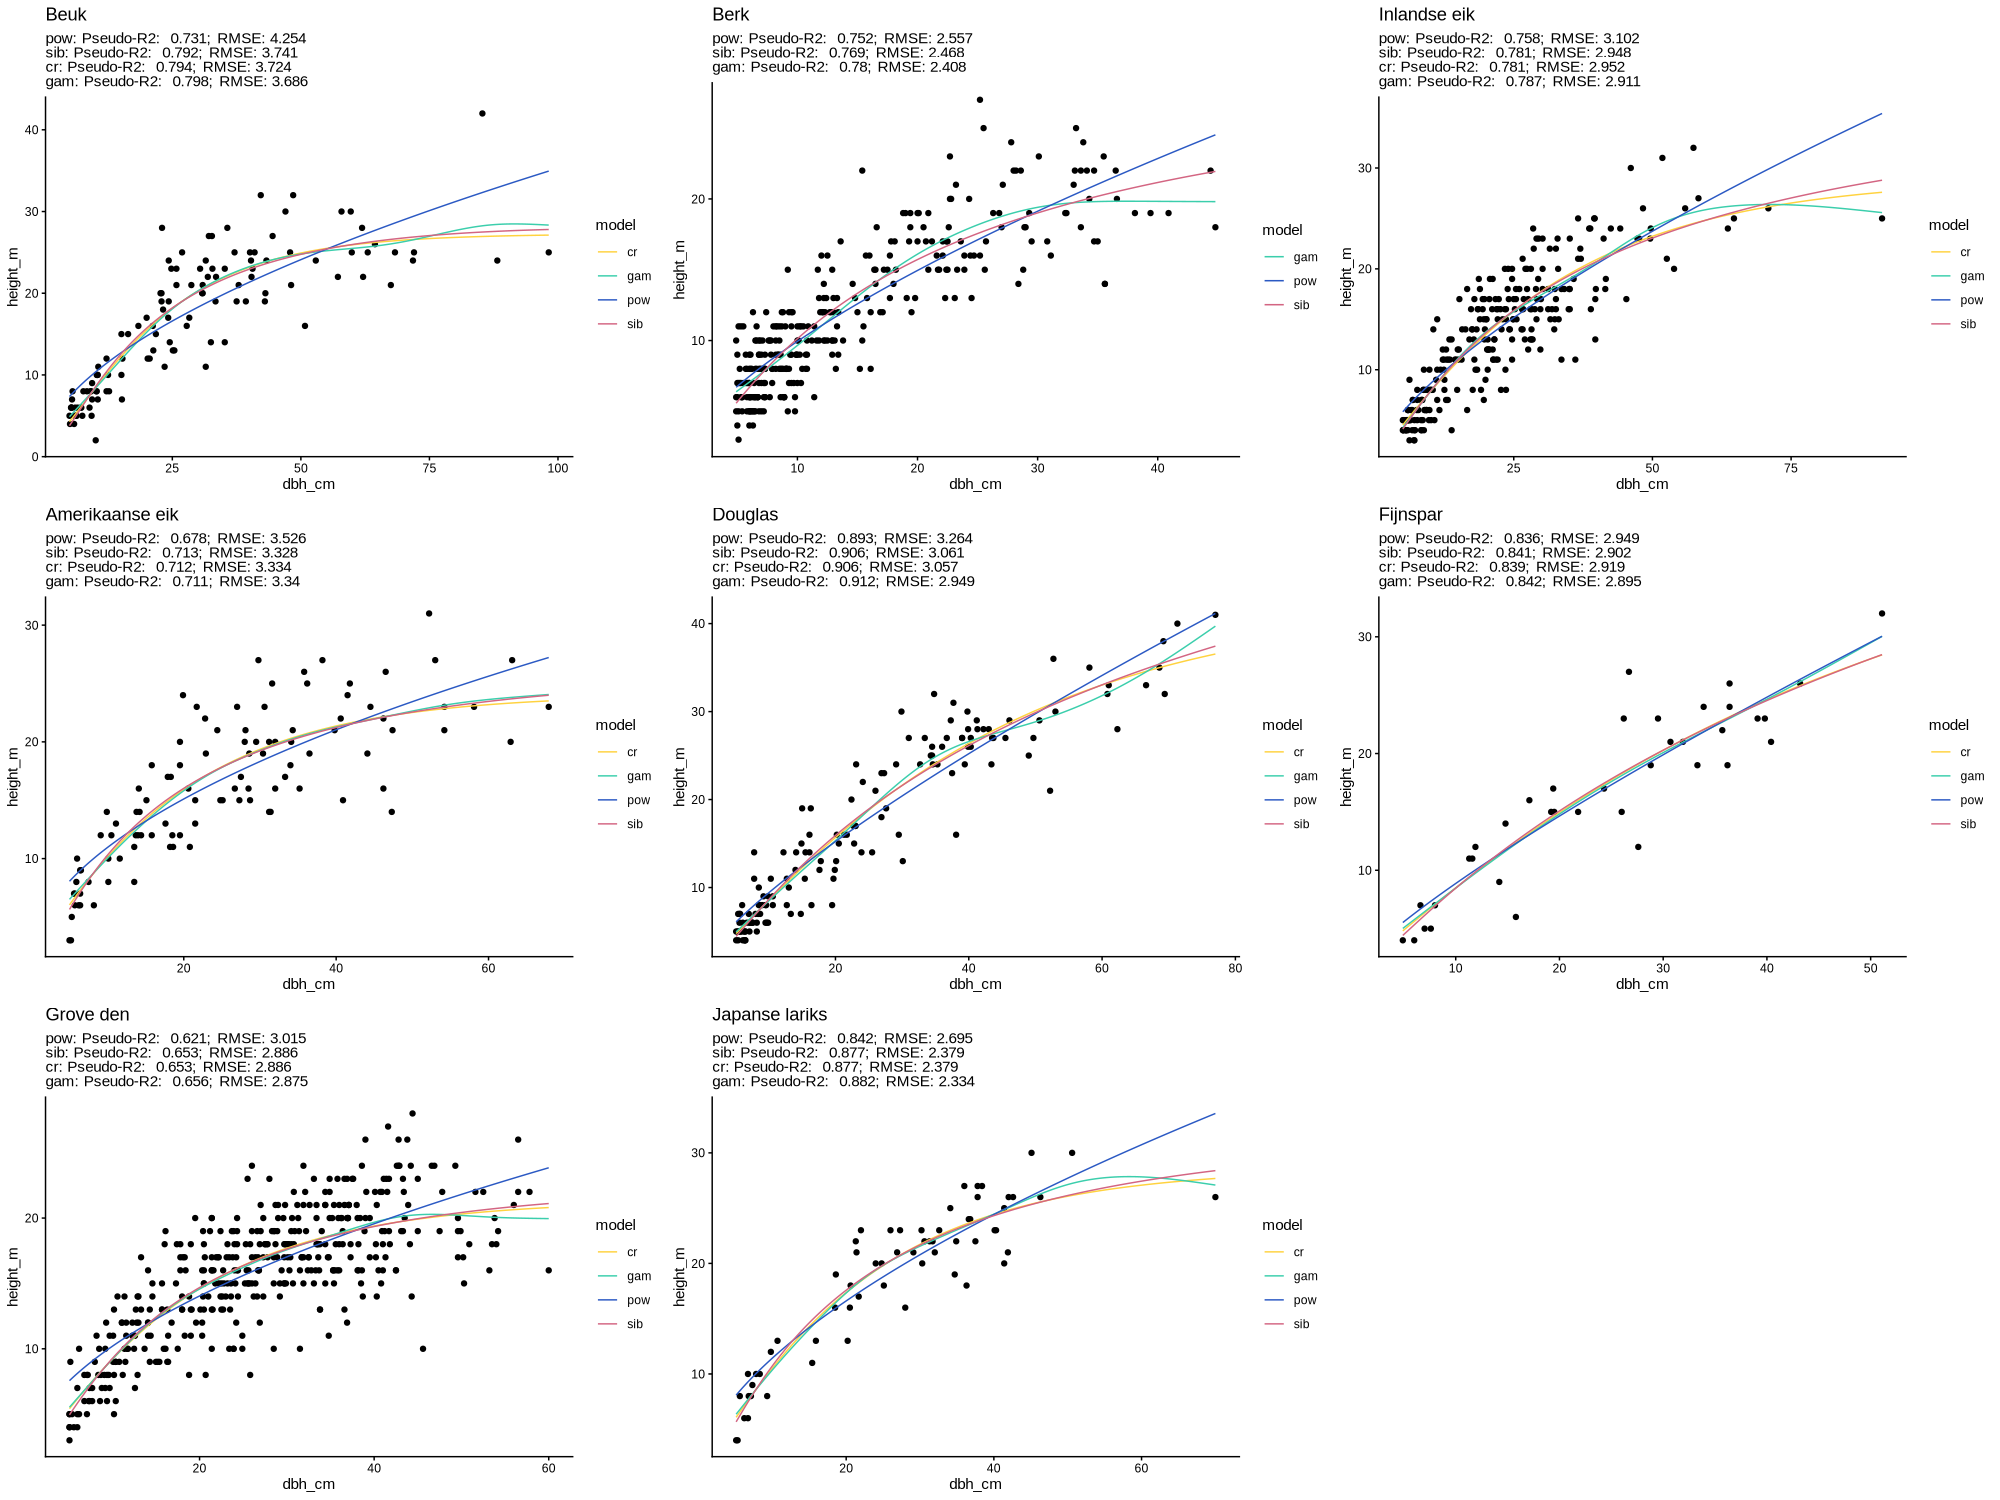

In [205]:
# Plot height-dbh model predictions for each species
# non-convergent models are not displayed
colour_vector <- c("pow" = "#2b59c3", "sib" = "#d36582", "cr" = "#ffd23f", "gam" = "#3bceac")
                         
plot_list <- purrr::map(
    .x = species_list,
    .f = ~{
        
        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == .x)

        models <- purrr::compact(model_outputs[[which(species_list == .x)]]) # remove non-convergent models

        # Add pseudo-r2 and rmse for each model
        subtitle <- purrr::map2_chr(.x = models, 
                                    .y = names(models),
                                    .f = ~paste0(.y,": ", "Pseudo-R2:&nbsp;", round(pseudo_r2(selected_data$height_m, fitted(.x)), 3), ";&nbsp;RMSE:&nbsp;", round(rmse(selected_data$height_m, fitted(.x)), 3))) |>
            paste(collapse = "<br>")
        
        ggplot2::ggplot() +
            ggplot2::geom_point(data = selected_data, mapping = ggplot2::aes(x = dbh_cm, y = height_m)) +
            ggplot2::geom_line(data = pred_outputs[[which(species_list == .x)]], mapping = ggplot2::aes(x = dbh, y = height, color = model, group = model)) +
            ggplot2::scale_colour_manual(values = colour_vector) +
            ggplot2::labs(title = .x, subtitle = subtitle) +
            ggplot2::theme_classic() +
            ggplot2::theme(plot.subtitle = ggtext::element_markdown())
        
    }
)

options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
cowplot::plot_grid(plotlist = plot_list)
#ggplot2::ggsave(filename = "height-dbh_veluwe.png", dpi = 300, height = 12, width = 12)

> **Conclusion**
> 
> - The *generalised additive model* had the highest $R^2$ and lowest root mean squared error values for all species.
> - Out of the parametric models, *Sibbesen* ranked best. The *power* model scored consistently lower. *Chapman-Richards* was very close to *Sibbesen*, but failed to convergence for birch (berk).

#### Part 2b: Estimate age from height
The Forest Ecology and Forest Management Group at WUR has done extensive work on the growth and production of common tree species in the Netherlands. These reports include height-age models that we will apply here.

List of reports:

- Scots pine (grove den, *Pinus sylvestris*), Jansen et al. 2018a, https://edepot.wur.nl/444090
- Norway spruce (fijnspar, *Picea abies*), Jansen et al. 2018b, https://edepot.wur.nl/444089
- Japanese larch (Japanse lariks, *Larix kaempferi*), Jansen et al. 2018c, https://edepot.wur.nl/444088
- Beech (beuk, *Fagus sylvatica*), Jansen et al. 2018d, https://edepot.wur.nl/444094
- Birch (berk, *Betula pendula*), Jansen et al. 2018e, https://edepot.wur.nl/444102
- Pedunculate oak (inlandse eik, *Quercus robur*), Jansen et al. 2018f, https://edepot.wur.nl/444093
- Red oak (Amerikaanse eik, *Quercus rubra*), Jansen et al. 2018g, https://edepot.wur.nl/444098
- Douglas fir (douglasspar, *Pseudotsuga menziesii*), Jansen et al. 2016, https://doi.org/10.3920/978-90-8686-827-8

For most species, the Cieszewski model (Cieszweski 2001, https://doi.org/10.1139/x00-132) is applied, which takes the form:  
$
H = h_x ({t^{c_1}[{x^{c_1}R + c_2}]}) / ({x^{c_1}[{t^{c_1}R + c_2}]})
$,   
    where $h_x$ is the height at reference age $x$, which can be considered a site index,   
    $R = Z + \sqrt{Z^2+\frac{2c_2h_x}{x^{c_1}}}$  
    and $Z = h_x - c_3$

For red oak and douglas fir (for $h > 7$ meters), the Chapman-Richards model is applied, which takes the form:  
$
H = h_x (1 - e^{-c_1t})^b
$,  
where $b = c_2 - c_3h_x$

For douglas fir ($h \leq 7$ meters), the Korf model (Wenk et al. 1990) is applied, which takes the form:
$
H = 7 (e^{-at^{b}})/(e^{-a{t_{7}}^{b}})
$

Before we can calculate age from height, we need to estimate the site indices ($h_x$) for each species on the Veluwe.

In [255]:
# Create table with parameters for species-specific height growth models, from WUR-FEM reports
height_growth_parameters <- tibble::tribble(
    # ref_age = reference age; c1, c2, c3, c4 are model parameters
    ~"species", ~"ref_age", ~"c1", ~"c2", ~"c3", ~"c4",
    # Jansen et al. 2018a, eq 10; c1, c2, c3 derived from Table 3, page 12
    "Grove den", 70L, 1.5162, 2500.5706, 22.0801, NA,
    # Jansen et al. 2018b, eq 9; c1, c2, c3 derived from Table 3, page 14
    "Fijnspar", 50L, 1.7859, 2181.7777, 29.2173, NA,
    # Jansen et al. 2018c, eq 12; c1, c2, c3 derived from Table 3 (North), page 15
    "Japanse lariks", 50L, 1.1565, 1259.1192, 34.2727, NA,
    # Jansen et al. 2018d, eq 12; c1, c2, c3 derived from Table 3, page 14
    "Beuk", 70L, 1.2165, 5653.0980, 14.2701, NA,
    # Jansen et al. 2018e, eq 7; c1, c2, c3 derived from Table 3, page 10
    "Berk", 50L, 1.3198, 1065.6372, 16.4603, NA,
    # Jansen et al. 2018f, eq 10; c1, c2, c3 derived from Table 3, page 11
    "Inlandse eik", 70L, 1.0690, 1449.4523, 34.2039, NA,
    # Jansen et al. 2019g, eq 7; c1, c2, c3 derived from Table 2, page 9
    "Amerikaanse eik", NA, 0.0199, 5.2936, 0.1462, NA,
    # Jansen et al. 2016, eq 31; c1-c4 derived from Table 7, page 38
    "Douglas", NA, 0.0278, 3.4405, 0.0557, 1.3872
)

# Create function to calculate height based on species, age (t) and the site index (boniteit)
calculate_height_from_age <- function(x, species, site_index) {

    # Get species-specific model parameters
    pars <- height_growth_parameters |> dplyr::filter(.data$species == {{species}})
    c1 <- pars$c1
    c2 <- pars$c2
    c3 <- pars$c3
    c4 <- pars$c4
    ref_age <- pars$ref_age
    t <- x

    if(species == "Amerikaanse eik" ) {

        b <- c2 - c3 * site_index
        h_top <- site_index * (1 - exp(-c1 * t))^b

    } else if(species == "Douglas") {

            b <- c2 - c3 * site_index
            t7 <- -log(1-(7 / site_index)^(1 / b)) / c1
            ak <- (c1 * b * (site_index / 7) * exp(-c1 * t7) * (1 - exp(-c1 * t7))^(b-1)) / (c4 * t7^(-c4 - 1))

            h_top <- dplyr::if_else(t <= t7, 
                                    7 * (exp(-ak * t^(-c4))) / (exp(-ak * t7^(-c4))),
                                    site_index * (1 - exp(-c1 * t))^b)
                               
    } else {

        Z <- site_index - c3
        R <- Z + sqrt(Z^2 + (2 * c2 * site_index) / (ref_age^c1))
        h_top <- site_index * ((t^c1) * ((ref_age^c1) * R + c2)) / ((ref_age^c1) * ((t^c1) * R + c2))
        
    }

    h_top
    
}

In [207]:
# Nonlinear least squares approach to finding the species-specific site indices for the Veluwe
site_indices <- purrr::map(
    .x = species_list,
    .f = ~{
        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == {{.x}}) |>
            dplyr::rename("height" = "height_m", "t" = "age")
    
        pars <- height_growth_parameters |> dplyr::filter(.data$species == {{.x}})
        c1 <- pars$c1
        c2 <- pars$c2
        c3 <- pars$c3
        c4 <- pars$c4
        ref_age <- pars$ref_age
    
        # NB: For finding the site index, we use a simpler model for Douglas (Pseudotsuga menziesii) because the two-step model by Jansen et al. 2016 is too complicated to optimise
        # i.e., we use the logistic growth model for the full range of ages instead of only for the ages when height > 7 meters
        if(.x %in% c("Amerikaanse eik", "Douglas")) {
            
            mod <- nls(height ~ site_index * (1 - exp(-c1 * t))^(c2 - c3 * site_index), 
                       data = selected_data, start = list(site_index = 20), ...)
            
        } else {
    
            mod <- nls(height ~ site_index * ((t^c1) * ((ref_age^c1) * ((site_index - c3) + sqrt((site_index - c3)^2 + (2 * c2 * site_index) / (ref_age^c1))) + c2)) / ((ref_age^c1) * ((t^c1) * ((site_index - c3) + sqrt((site_index - c3)^2 + (2 * c2 * site_index) / (ref_age^c1))) + c2)),
                       data = selected_data, start = list(site_index = 25), ...)
        }

        return(mod)
    })

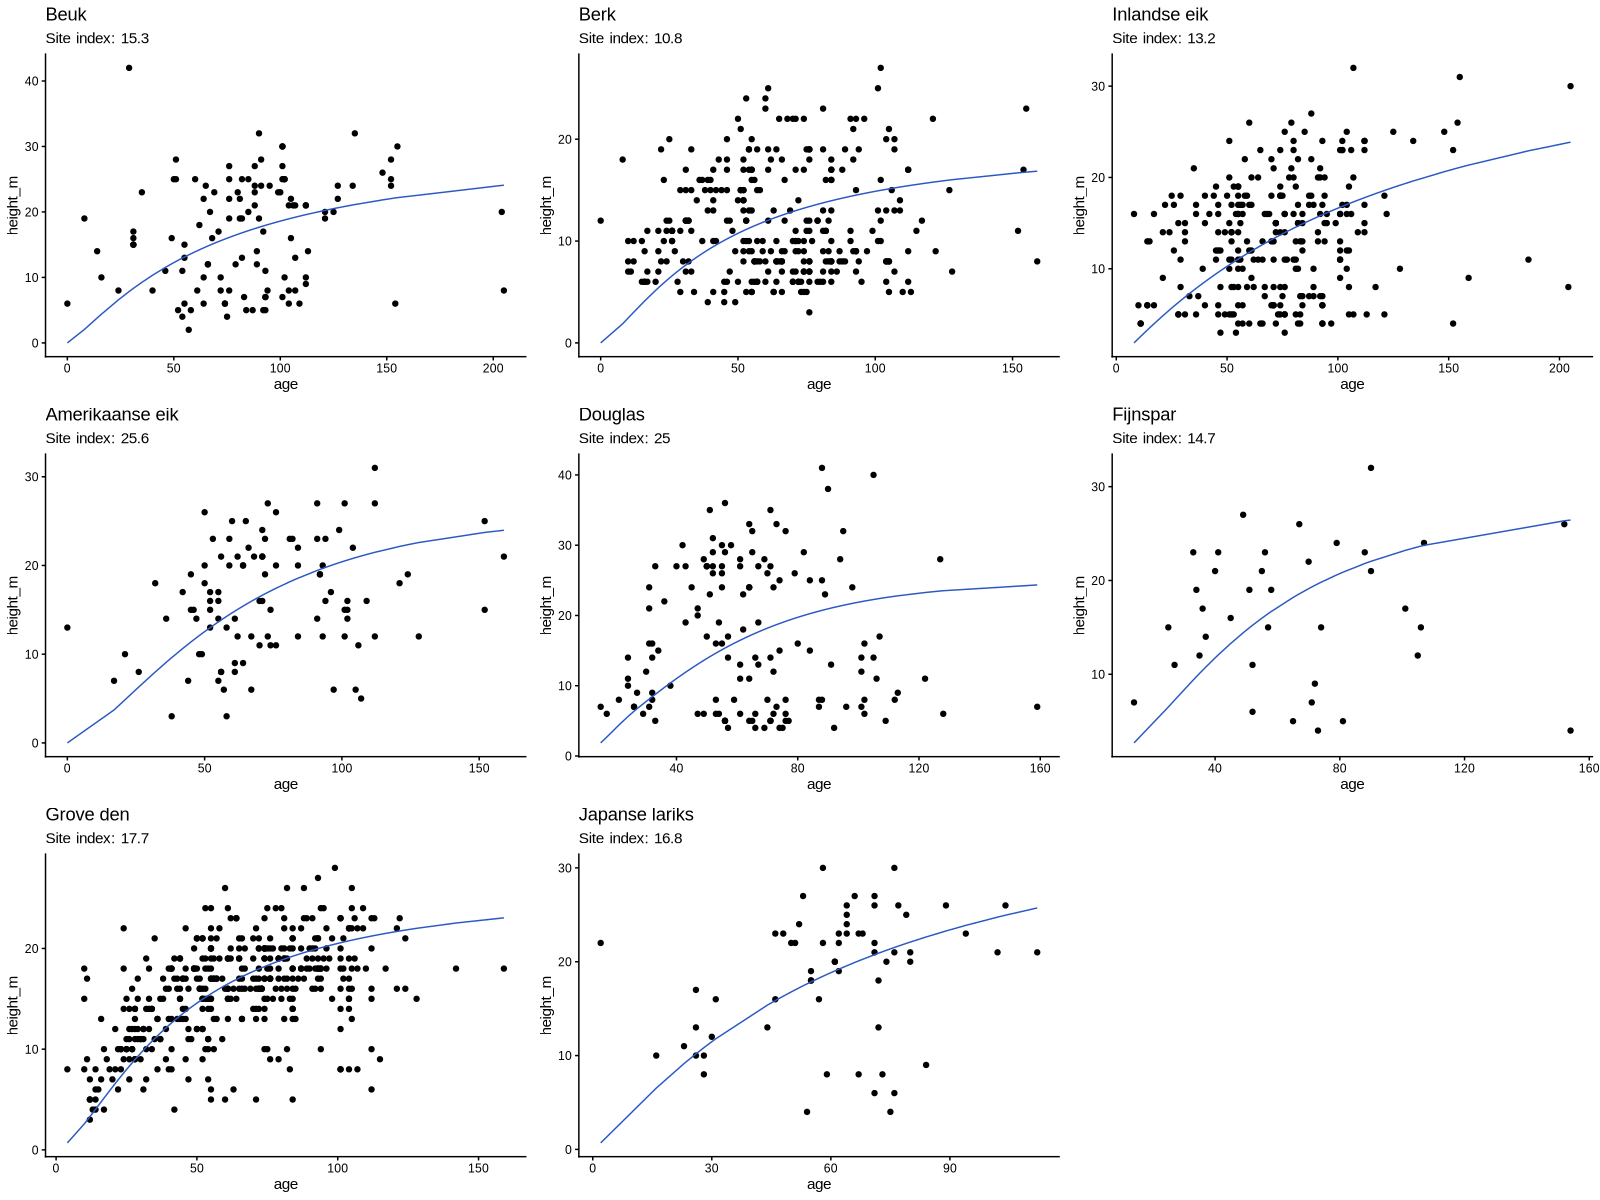

In [256]:
plot_list <- purrr::map2(
    .x = species_list,
    .y = site_indices,
    .f = ~{
        
        selected_data <- veluwe_sample_trees |> dplyr::filter(.data$species_name == .x) |>
            dplyr::mutate(htop = calculate_height_from_age(x = age, species = .x, site_index = coefficients(.y)))

        subtitle <- paste0("Site index: ", round(coefficients(.y), 1))
        
        selected_data |>   
            ggplot2::ggplot() +
            ggplot2::geom_point(mapping = ggplot2::aes(x = age, y = height_m)) +
            ggplot2::geom_line(mapping = ggplot2::aes(x = age, y = htop), color = colour_vector[1]) +
            ggplot2::labs(title = .x, subtitle = subtitle) +
            ggplot2::theme_classic() +
            ggplot2::theme(plot.subtitle = ggtext::element_markdown())
        
    }
)

options(repr.plot.width = 16, repr.plot.height = 12, repr.plot.res = 100)
cowplot::plot_grid(plotlist = plot_list)

In [289]:
# Reverse height-age model to find age for given height
find_age <- function(height, species, site_index, lower = 10, upper = 1000) {

    a <- species
    b <- site_index

    sapply(height, function(height) uniroot(function(x) calculate_height_from_age(species = a, site_index = b, x) - height, 
                                            lower = lower, upper = upper)$root)
    
}

find_age(height = 3:23, species = "Grove den", site_index = coefficients(site_indices[[which(species_list == "Grove den")]]))

[1]  11.18704  13.92264  16.62729  19.35819  22.15851  25.06601  28.11788
 [8]  31.35362  34.81803  38.56389  42.65593  47.17581  52.22947  57.95842
[15]  64.55747  72.30455  81.61313  93.13068 107.94082 128.02565 157.50347

> **Conclusion**  
> We can only get some indicator of age for a limited range of heights, because the asymptotic growth model.